In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
missing_train = df_train.isnull().sum()
missing_train[missing_train > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
missing_test = df_test.isnull().sum()
missing_test[missing_test > 0].sort_values(ascending=False)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Exterior1st        1
Exterior2nd        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64

In [8]:
X=df_train.drop(['Id', 'SalePrice'], axis=1)

In [9]:
y= df_test.drop(['Id'], axis=1)

In [10]:
y = df_train['SalePrice']

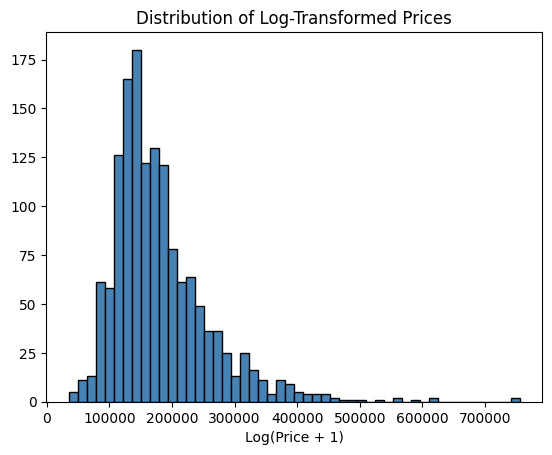

In [11]:
plt.hist(y, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Log-Transformed Prices')
plt.xlabel('Log(Price + 1)')
plt.show()

In [12]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
import xgboost as xgb

In [14]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('None')
    else:
        X[col] = X[col].fillna(0)

In [15]:
train = pd.DataFrame()
label = LabelEncoder()

for c in X.columns:
    if X[c].dtype == 'object':
        train[c] = label.fit_transform(X[c])
    else:
        train[c] = X[c]

In [16]:
train = train.fillna(train.mean())

In [17]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,1,3,3,0,4,...,0,0,3,4,1,0,2,2008,8,4
1,20,3,80.0,9600,1,1,3,3,0,2,...,0,0,3,4,1,0,5,2007,8,4
2,60,3,68.0,11250,1,1,0,3,0,4,...,0,0,3,4,1,0,9,2008,8,4
3,70,3,60.0,9550,1,1,0,3,0,0,...,0,0,3,4,1,0,2,2006,8,0
4,60,3,84.0,14260,1,1,0,3,0,2,...,0,0,3,4,1,0,12,2008,8,4


In [18]:
def xgboost_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
    model = xgb.XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print('RMSE : ', rmse) 

In [19]:
xgboost_model(train, y)

RMSE :  25987.3322986412


# One-Hot Encoding with pd.get_dummies()

In [20]:
X = df_train.drop(['SalePrice'], axis=1)
X = X.drop(['Id'], axis=1)
y = np.log1p(df_train['SalePrice'])

In [21]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('None')
    else:
        X[col] = X[col].fillna(0)

In [22]:
X_encoded = pd.get_dummies(X, drop_first=False)

In [23]:
X_encoded = X_encoded.fillna(X_encoded.mean())

In [24]:
X_encoded.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,True,False,False,False,False,True,False


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, test_size=0.2)
model = xgb.XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('One-Hot RMSE:', rmse) 

One-Hot RMSE: 0.13317803072343778


In [26]:
test_clean = df_test.drop(['Id'], axis=1)

In [27]:
for col in test_clean.columns:
    if test_clean[col].dtype == 'object':
        test_clean[col] = test_clean[col].fillna('None')
    else:
        test_clean[col] = test_clean[col].fillna(0)

In [28]:
test_encoded = pd.DataFrame()

In [29]:
for c in test_clean.columns:
    if test_clean[c].dtype == 'object':
        le = LabelEncoder()
        combined = pd.concat([X[c], test_clean[c]], axis=0)
        le.fit(combined.astype(str))
        test_encoded[c] = le.transform(test_clean[c])
    else:
        test_encoded[c] = test_clean[c]

In [30]:
test_encoded = test_encoded.fillna(test_encoded.mean())

In [31]:
final_model = xgb.XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42)
final_model.fit(train, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
test_preds_log = final_model.predict(test_encoded)
test_preds = np.expm1(test_preds_log)

In [33]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': test_preds
})
submission.to_csv('submission.csv', index=False)

In [34]:
submission.head()

,Id,SalePrice
0,1461,121846.148438
1,1462,154880.656250
2,1463,176179.390625
3,1464,181143.250000
4,1465,176931.187500


In [35]:
print('Label Encoding RMSE :', rmse)
print('One-Hot Encoding RMSE:', rmse)

if rmse < rmse:
    print('Winner: Label Encoding')
else:
    print('Winner: One-Hot Encoding')

Label Encoding RMSE : 0.13317803072343778
One-Hot Encoding RMSE: 0.13317803072343778
Winner: One-Hot Encoding
